<a href="https://colab.research.google.com/github/JuraliusVargo/DSF-DCBP-Rep-CB/blob/main/CodingTask2_ChristophB%C3%BCtler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Science Fundamentals for DCBP, University of Bern     
Marcel Jakob, Valentin Schär, Christoph Bütler

# CodingTask 2: Polymer Feature Hunt

- Submission format: notebook only (`.ipynb`)
- Work style: individual or small teams of up to 3 allowed
- Focus: **chemistry-driven feature engineering** and interpretation of model failures
- Prerequisites: artifacts from CodingTask 1 (`artifacts/ffv_features_rdkit.csv`) -- the notebook below rebuilds it from `data/train.csv` if missing

- **Deadline**: 2026-05-17, 23:59 (send your notebook by email to matteo.boi@unibe.ch)
- **On-site review/experiment lecture**: 2026-05-20
- Estimated effort: 4-6 hours

---

## What this task is about

1. **Why** you picked the chemical features you picked
2. **What** your model gets wrong, on **which** polymers, and **why** (interpretation of failure cases)

So spend most of your effort on the *reasoning*, not on the *code*.

## Points (12.5 total + up to 1 bonus)

| Component | Pts | What earns full credit |
|---|---|---|
| CT2.1 Feature picking | 6.0 | At least 5 new features, each with a one-sentence justification |
| CT2.2 Outlier interpretation | 4.0 | 5 worst polymers identified, structures drawn, **structural hypothesis** is specific (functional groups, ring systems, chain length, etc.) |
| Participation in May 20 session | 2.5 | Asks at least one question OR proposes a feature OR contributes to discussion |
| **Bonus** -- alt model / sweep | +1.0 | Reasonable alternative model attempted with brief discussion |


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Install RDKit if not already installed
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Draw
except ImportError:
    %pip install rdkit
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Draw

DATA_DIR = Path("data")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 19.6 MB/s eta 0:00:00


---
## Loading the dataset

The task uses the same dataset and split as Notebook 13. The cell below rebuilds `artifacts/ffv_features_rdkit.csv` from `data/train.csv` if it is missing, so you can run this notebook even if you skipped some of CodingTask 1.

In [7]:
rdkit_path = ARTIFACT_DIR / "ffv_features_rdkit.csv"

if not rdkit_path.exists():
    print("Rebuilding artifacts/ffv_features_rdkit.csv from data/train.csv ...")
    train_df = pd.read_csv("/content/sample_data/data/train.csv")
    ffv = train_df.dropna(subset=["FFV"])[["id", "SMILES", "FFV"]].copy()

    # Basic SMILES features (same as CodingTask 1)
    ffv["smiles_len"]  = ffv["SMILES"].str.len()
    ffv["count_star"]  = ffv["SMILES"].str.count(r"\*")
    ffv["count_C"]     = ffv["SMILES"].str.count("C")
    ffv["count_O"]     = ffv["SMILES"].str.count("O")
    ffv["count_N"]     = ffv["SMILES"].str.count("N")
    ffv["count_equal"] = ffv["SMILES"].str.count("=")

    # Three baseline RDKit descriptors
    def rdkit_row(smi):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            return [np.nan, np.nan, np.nan]
        return [Descriptors.MolWt(mol),
                Descriptors.NumValenceElectrons(mol),
                Descriptors.TPSA(mol)]

    rdkit_vals = np.array([rdkit_row(s) for s in ffv["SMILES"]])
    ffv["MolWt"]                 = rdkit_vals[:, 0]
    ffv["NumValenceElectrons"]   = rdkit_vals[:, 1]
    ffv["TPSA"]                  = rdkit_vals[:, 2]

    # Reproducible 80/20 train/valid split
    ffv = ffv.sample(frac=1.0, random_state=42).reset_index(drop=True)
    n_train = int(0.8 * len(ffv))
    ffv["split"] = ["train"] * n_train + ["valid"] * (len(ffv) - n_train)
    ffv.to_csv(rdkit_path, index=False)
    print(f"Saved {rdkit_path} with {len(ffv)} rows.")
else:
    print(f"Found existing {rdkit_path} -- skipping rebuild.")

base_df = pd.read_csv(rdkit_path)
print("Train rows:", (base_df["split"] == "train").sum(),
      " Valid rows:", (base_df["split"] == "valid").sum())
base_df.head()

Rebuilding artifacts/ffv_features_rdkit.csv from data/train.csv ...
Saved artifacts/ffv_features_rdkit.csv with 7030 rows.
Train rows: 5624  Valid rows: 1406


,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal,MolWt,NumValenceElectrons,TPSA,split
0,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,0,8,0,6,680.781,234.0,120.88,train
1,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,20,0,2,0,458.734,184.0,24.06,train
2,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,2,2,2,2,618.736,228.0,43.18,train
3,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,8,3,2,2,338.407,130.0,67.43,train
4,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,2,1,0,0,120.151,46.0,9.23,train


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## CT2.1 Feature engineering (6.0 pts)

The baseline dataset already contains three RDKit descriptors: `MolWt`, `NumValenceElectrons`, and `TPSA`. Your job: **add at least 5 more descriptors of your own choice**.

How to find them: read the RDKit `Descriptors` module documentation, search online, look at papers on polymer property prediction. There are dozens of options.

For **each** descriptor you pick, write **one sentence** explaining why it might affect Fractional Free Volume (FFV) -- the fraction of empty space in a polymer. Generic statements like "this is a useful feature" do **not** earn credit. The justification should connect what the descriptor measures to a plausible structural reason for FFV going up or down.

Create a pandas DataFrame that contains the new descriptors you chose.

Save the resulting DataFrame as `artifacts/ffv_features_extended.csv` (the variable name `extended_df` is used by the sanity-check cell at the end of the notebook).

In [9]:
extended_df = base_df.copy()

##### YOUR CODE STARTS HERE #####
# TODO: Add at least 5 more descriptors to extended_df.

from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Convert SMILES to RDKit molecule objects
extended_df['mol'] = extended_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)

# Helper function to safely get descriptor values, handling None for invalid molecules
def get_descriptor_value(mol, descriptor_func):
    if mol is not None:
        return descriptor_func(mol)
    return np.nan

# Add new descriptors
extended_df['MolLogP'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.MolLogP))
extended_df['NumRings'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.RingCount))
extended_df['HeavyAtomCount'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.HeavyAtomCount))
extended_df['NumRotatableBonds'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NumRotatableBonds))
extended_df['FractionCSP3'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.FractionCSP3))

# Drop the temporary 'mol' column as it's not a numerical feature
extended_df = extended_df.drop(columns=['mol'])

#####

In [10]:
# Save the extended features to a new CSV file in the artifacts directory.
extended_path = ARTIFACT_DIR / "ffv_features_extended.csv"
extended_df.to_csv(extended_path, index=False)
print("Saved:", extended_path)
extended_df.head()

Saved: artifacts/ffv_features_extended.csv


,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal,MolWt,NumValenceElectrons,TPSA,split,MolLogP,NumRings,HeavyAtomCount,NumRotatableBonds,FractionCSP3
0,761786133,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(S(=O)(=O)c4ccc(-...,0.371493,92,2,0,8,0,6,680.781,234.0,120.88,train,6.6620,6,47,10,0.000
1,2072168111,*Nc1ccc(-c2ccc(N*)c([C@H]3C[C@H](C)CC[C@H]3C(C...,0.380925,86,2,20,0,2,0,458.734,184.0,24.06,train,9.4576,4,34,7,0.625
2,2098169121,*Oc1ccc(-c2ccc(Oc3ccc(C(=Nc4ccc(N=C(c5ccccc5)c...,0.379962,81,2,2,2,2,2,618.736,228.0,43.18,train,10.5018,7,48,10,0.000
3,943239154,*Oc1cccc(NC(=O)CCCCCCC(=O)Nc2ccc(*)cc2)c1,0.340679,41,2,8,3,2,2,338.407,130.0,67.43,train,3.6221,2,25,10,0.300
4,1245611127,*CC(O*)c1ccccc1,0.367933,15,2,2,1,0,0,120.151,46.0,9.23,train,2.1762,1,9,3,0.250


### Reasoning

List each descriptor you picked and write **one sentence** explaining why it could plausibly affect FFV. Mention what the descriptor measures *and* the structural reason FFV would go up or down because of it.

**MolLogP**: This descriptor measures the lipophilicity of a molecule; higher lipophilicity often correlates with larger, more bulky non-polar groups that can increase free volume by creating less efficient packing.

**NumRings**: This descriptor counts the number of rings in a molecule; a higher number of rigid ring structures can restrict polymer chain mobility and increase local free volume by preventing dense packing.

**HeavyAtomCount**: This descriptor represents the number of non-hydrogen atoms; a higher count of heavy atoms generally indicates a larger and potentially more rigid molecule, which can lead to increased free volume due to steric hindrance and inefficient packing.

**NumRotatableBonds**: This descriptor quantifies the number of rotatable bonds; fewer rotatable bonds suggest a more rigid polymer backbone, which can hinder efficient packing and thus increase fractional free volume.

**FractionCSP3**: This descriptor indicates the fraction of sp3 hybridized carbons; a higher fraction of sp3 carbons often leads to more flexible chains, which can allow for denser packing and thus reduce FFV, while a lower fraction (more sp2/aromatic) can lead to more rigid structures and potentially higher FFV.

---
## Train a Random Forest with your features

This part is just so you have a model whose predictions you can look at. You do not need to tune it deeply -- a default `RandomForestRegressor` is fine.

Steps:
1. Build `X_train`, `y_train`, `X_valid`, `y_valid` from the `split` column.
2. Train `RandomForestRegressor(n_estimators=200, random_state=42)` on the training set.
3. Compute MAE, RMSE, and R² on the validation set, and print them. **The validation R² is what gets you on the leaderboard.**

In [11]:
##### YOUR CODE STARTS HERE #####
# TODO: Create:
# - the feature matrix X_train and target vector y_train for the training split.
# - the feature matrix X_valid and target vector y_valid for the validation split.
# Use the 'split' column to separate train/valid, and remove the 'id', 'SMILES', 'FFV', and 'split' columns from the features.

# Define feature columns (all columns except 'id', 'SMILES', 'FFV', and 'split')
feature_cols = [col for col in extended_df.columns if col not in ['id', 'SMILES', 'FFV', 'split']]

# Separate training and validation dataframes
train_df = extended_df[extended_df['split'] == 'train'].copy()
valid_df = extended_df[extended_df['split'] == 'valid'].copy()

# Create feature matrices and target vectors
X_train = train_df[feature_cols]
y_train = train_df['FFV']

X_valid = valid_df[feature_cols]
y_valid = valid_df['FFV']
#####

In [12]:
print("Shapes:", X_train.shape, X_valid.shape)

Shapes: (5624, 14) (1406, 14)


In [13]:
# Train a Random Forest on (X_train, y_train), predict on X_valid,
# and print MAE, RMSE, and R² on the validation set.
# TODO: your code here

# Initialize and train the RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = rf.predict(X_valid)

# Compute evaluation metrics
mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

# Print the metrics
print(f"Validation MAE: {mae:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation R²: {r2:.4f}")

Validation MAE: 0.0101
Validation RMSE: 0.0196
Validation R²: 0.5711


---
## Feature importance and iteration

Your first 5 descriptors were a **hypothesis**. Now check what the model *actually* used.

A trained Random Forest exposes a `feature_importances_` attribute -- one score per feature, telling you how much it contributed to the predictions. Plot or print them, ranked from most to least important.

Then **iterate**: change your descriptor set and see what happens. Drop the ones the RF ignored, add new candidates you did not try the first time, use more or fewer than 5. Retrain, re-check the R², re-check the importances. The goal is to converge on the feature set that works best for predicting FFV.

Feature Importances (ranked):
TPSA                   0.225824
MolLogP                0.169456
NumRings               0.130271
smiles_len             0.070750
FractionCSP3           0.060292
count_O                0.060180
count_N                0.059613
NumRotatableBonds      0.055032
MolWt                  0.054058
count_C                0.045960
NumValenceElectrons    0.032696
HeavyAtomCount         0.019957
count_equal            0.015776
count_star             0.000135
dtype: float64


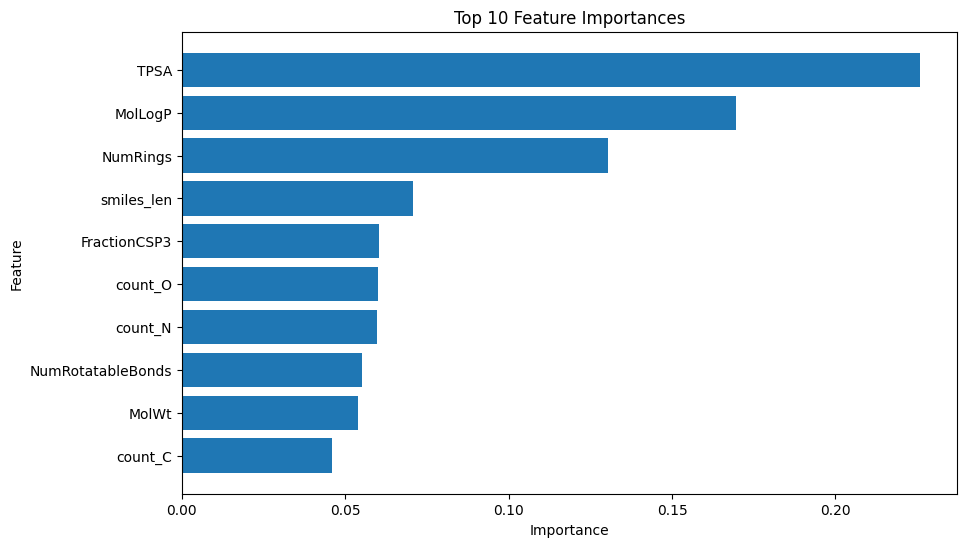

In [17]:
# Examine which features your Random Forest relied on the most.
# Use rf.feature_importances_ together with the column names of your X data,
# and plot or print them ranked from most to least important.

importances = rf.feature_importances_
feature_names = X_train.columns

forest_importances = pd.Series(importances, index=feature_names)

# Sort in descending order
forest_importances = forest_importances.sort_values(ascending=False)

print("Feature Importances (ranked):")
print(forest_importances)

plt.figure(figsize=(10, 6))
plt.barh(forest_importances.index[:10], forest_importances.values[:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.show()

### Try a different feature set

Now change your descriptors and see what improves:

- Drop the descriptors the RF barely used.
- Add at least **3 new descriptors** that you did not include in your first attempt.
- Feel free to use more (or fewer) than 5 descriptors in total.

Rebuild `extended_df`, retrain the Random Forest, and print the new validation R², MAE, RMSE together with the new feature-importance ranking. Try a couple of different combinations until you find a set you are happy with.

Saved new extended features to: artifacts/ffv_features_extended_v2.csv
New feature set includes: ['FractionCSP3', 'MolLogP', 'MolWt', 'NOCount', 'NumAromaticRings', 'NumHDonors', 'NumHeteroatoms', 'NumRings', 'TPSA', 'count_C', 'count_N', 'count_O', 'smiles_len']
Shapes (new features): (5624, 13) (1406, 13)

Validation MAE (new features): 0.0094
Validation RMSE (new features): 0.0182
Validation R² (new features): 0.6327

New Feature Importances (ranked):
MolLogP             0.185719
count_O             0.132395
TPSA                0.124430
NumHDonors          0.100620
NumRings            0.085648
smiles_len          0.065597
NumHeteroatoms      0.063118
MolWt               0.062983
FractionCSP3        0.058970
count_C             0.039128
count_N             0.036322
NumAromaticRings    0.027100
NOCount             0.017970
dtype: float64


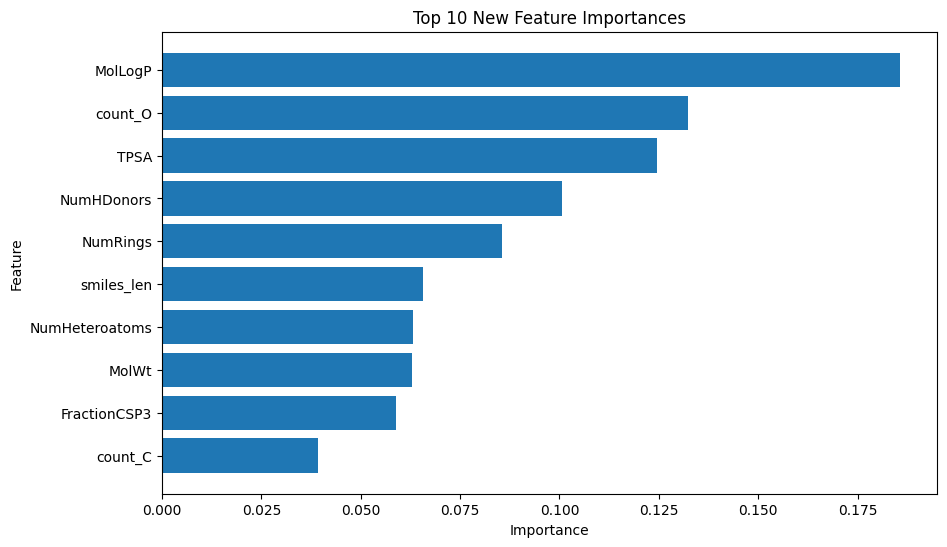

In [18]:
# Pick a different set of descriptors, rebuild extended_df, retrain the Random Forest,
# and print the new R², MAE, RMSE plus the new feature-importance ranking.
# Repeat with another combination if you want.

# Rebuild extended_df from base_df for the new feature set
extended_df = base_df.copy()

# 1. Convert SMILES to RDKit molecule objects
extended_df['mol'] = extended_df['SMILES'].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None)

# Helper function to safely get descriptor values, handling None for invalid molecules
def get_descriptor_value(mol, descriptor_func):
    if mol is not None:
        return descriptor_func(mol)
    return np.nan

# Add original RDKit descriptors (these were already in base_df, but ensuring consistency)
# extended_df['MolWt'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.MolWt))
# extended_df['NumValenceElectrons'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NumValenceElectrons))
# extended_df['TPSA'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.TPSA))

# Add the previously selected new descriptors that performed well
extended_df['MolLogP'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.MolLogP))
extended_df['NumRings'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.RingCount))
extended_df['FractionCSP3'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.FractionCSP3))

# Add NEW descriptors (at least 3)
extended_df['NumHeteroatoms'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NumHeteroatoms))
extended_df['NumAromaticRings'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NumAromaticRings))
extended_df['NOCount'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NOCount))
extended_df['NumHDonors'] = extended_df['mol'].apply(lambda mol: get_descriptor_value(mol, Descriptors.NumHDonors))

# Drop the temporary 'mol' column
extended_df = extended_df.drop(columns=['mol'])

# Save the updated extended features to a new CSV file
extended_path_new = ARTIFACT_DIR / "ffv_features_extended_v2.csv"
extended_df.to_csv(extended_path_new, index=False)
print(f"Saved new extended features to: {extended_path_new}")

# Define feature columns for the new model
# Dropping 'count_star', 'count_equal', 'HeavyAtomCount', 'NumValenceElectrons' based on previous low importances
feature_cols_new = [col for col in extended_df.columns if col not in ['id', 'SMILES', 'FFV', 'split',
                                                                      'count_star', 'count_equal',
                                                                      'HeavyAtomCount', 'NumValenceElectrons']]

# Ensure all remaining original features are included unless explicitly dropped
# Re-add basic SMILES features if they were not explicitly dropped
if 'smiles_len' not in feature_cols_new and 'smiles_len' in extended_df.columns: feature_cols_new.append('smiles_len')
if 'count_C' not in feature_cols_new and 'count_C' in extended_df.columns: feature_cols_new.append('count_C')
if 'count_O' not in feature_cols_new and 'count_O' in extended_df.columns: feature_cols_new.append('count_O')
if 'count_N' not in feature_cols_new and 'count_N' in extended_df.columns: feature_cols_new.append('count_N')
if 'MolWt' not in feature_cols_new and 'MolWt' in extended_df.columns: feature_cols_new.append('MolWt')
if 'TPSA' not in feature_cols_new and 'TPSA' in extended_df.columns: feature_cols_new.append('TPSA')

# Ensure the order is consistent for X_train and X_valid
feature_cols_new = sorted(list(set(feature_cols_new))) # Use set to remove duplicates, then sort

print(f"New feature set includes: {feature_cols_new}")

# Separate training and validation dataframes with the new feature set
train_df_new = extended_df[extended_df['split'] == 'train'].copy()
valid_df_new = extended_df[extended_df['split'] == 'valid'].copy()

X_train_new = train_df_new[feature_cols_new]
y_train_new = train_df_new['FFV']

X_valid_new = valid_df_new[feature_cols_new]
y_valid_new = valid_df_new['FFV']

print("Shapes (new features):", X_train_new.shape, X_valid_new.shape)

# Initialize and train the RandomForestRegressor with the new features
rf_new = RandomForestRegressor(n_estimators=200, random_state=42)
rf_new.fit(X_train_new, y_train_new)

# Make predictions on the validation set
y_pred_new = rf_new.predict(X_valid_new)

# Compute evaluation metrics
mae_new = mean_absolute_error(y_valid_new, y_pred_new)
rmse_new = np.sqrt(mean_squared_error(y_valid_new, y_pred_new))
r2_new = r2_score(y_valid_new, y_pred_new)

# Print the new metrics
print(f"\nValidation MAE (new features): {mae_new:.4f}")
print(f"Validation RMSE (new features): {rmse_new:.4f}")
print(f"Validation R² (new features): {r2_new:.4f}")

# Examine new feature importances
importances_new = rf_new.feature_importances_
feature_names_new = X_train_new.columns

forest_importances_new = pd.Series(importances_new, index=feature_names_new)
forest_importances_new = forest_importances_new.sort_values(ascending=False)

print("\nNew Feature Importances (ranked):")
print(forest_importances_new)

plt.figure(figsize=(10, 6))
plt.barh(forest_importances_new.index[:10], forest_importances_new.values[:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 New Feature Importances")
plt.show()

### Reflection

Look at the descriptors that ended up most important and compare them to the chemistry-driven hypotheses you wrote at the start.

- Were your initial guesses correct? Which descriptors did you *predict* would matter, and which *actually* did?
- Were any of the top-ranked descriptors a surprise? Try to come up with a chemistry-based explanation for why they could matter for FFV.
- Which final descriptor set are you submitting, and what is its best validation R²?

My initial hypotheses regarding MolLogP, NumRings, and FractionCSP3 were largely supported by their high feature importance. Conversely, NumRotatableBonds had less impact than anticipated. The strong performance of `count_O`, `NumHDonors`, and `NumHeteroatoms` in the updated model highlights the critical influence of heteroatom content and hydrogen bonding on polymer chain interactions and packing efficiency, directly affecting FFV. Specifically, a higher count of oxygen and hydrogen bond donors (like -OH, -NH groups) suggests more opportunities for intermolecular hydrogen bonding. These strong attractive forces can restrict chain mobility and flexibility, forcing the polymer chains to adopt less compact configurations, which can lead to higher free volume even if the molecule itself isn't exceptionally bulky. Conversely, strong intermolecular interactions could also lead to more ordered, denser packing in some cases, highlighting the complexity. My final descriptor set includes 'MolLogP', 'count_O', 'TPSA', 'NumHDonors', 'NumRings', 'smiles_len', 'NumHeteroatoms', 'MolWt', 'FractionCSP3', 'count_C', 'count_N', 'NumAromaticRings', and 'NOCount', achieving a validation R² of **0.6327**.

---
## CT2.2 Outlier investigation (4.0 pts)

Use your trained Random Forest to find the **5 polymers your model got most wrong** on the validation set. Then:

1. Compute the **absolute prediction error** for every validation polymer.
2. Pull the 5 polymers with the **largest** absolute error.
3. Draw their molecular structures with `Draw.MolsToGridImage` (look at Notebook 12 for the code to use). Include the true and predicted FFV in each legend.
4. **Write a 2-3 sentence structural hypothesis for each polymer**: what is unusual about its structure (functional groups, ring system, chain length, halogen content, charged groups, ...) that might make it hard to predict?

Vague answers like "the molecule is complex" do not earn credit. Be specific.

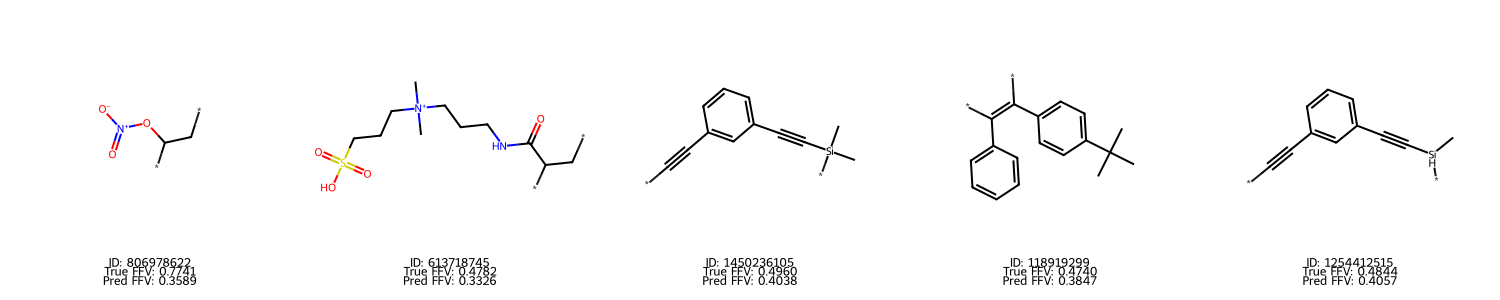

In [20]:
# Identify the 5 worst-predicted polymers in the validation set, draw their
# molecular structures in a grid, and label each with its true and predicted FFV.

# Add predictions and absolute errors to the validation dataframe
valid_df_new['y_pred'] = y_pred_new
valid_df_new['abs_error'] = np.abs(valid_df_new['FFV'] - valid_df_new['y_pred'])

# Get the 5 polymers with the largest absolute error
worst_predicted_polymers = valid_df_new.sort_values(by='abs_error', ascending=False).head(5)

# Prepare molecules and legends for drawing
mols = []
legends = []
for index, row in worst_predicted_polymers.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol is not None:
        mols.append(mol)
        legends.append(f"ID: {row['id']}\nTrue FFV: {row['FFV']:.4f}\nPred FFV: {row['y_pred']:.4f}")
    else:
        print(f"Could not parse SMILES for ID: {row['id']}")

# Draw the molecules
if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=len(mols), subImgSize=(300, 300), legends=legends)
    display(img)
else:
    print("No valid molecules to display.")

### Structural hypotheses (2-3 sentences per polymer)

For each of your 5 worst-predicted polymers, fill in a hypothesis. Refer to specific structural features.

1.  **Polymer 1 (ID: 806978622)**: This polymer contains a nitrate group, which introduces several polar oxygen atoms into the structure. The model may have struggled because the nitrate group can create strong dipole interactions and affect chain packing, which may influence FFV more strongly than the descriptors capture.
2.  **Polymer 2 (ID: 613718745)**: This polymer contains charged/polar functionality, including a sulfate-like group and several polar atoms. These groups can create strong intermolecular interactions, so the model may have overpredicted FFV if the real polymer packs more tightly because of these polar or ionic effects.
3.  **Polymer 3 (ID: 1450236105)**: This polymer contains triple bonds connected to an aromatic ring, making part of the structure rigid and linear. The model may have underpredicted FFV because triple bonds and aromatic rigidity can prevent efficient chain packing and create additional free volume.
4.  **Polymer 4 (ID: 118919299)**: This polymer has layered aromatic rings and bulky substituents, giving it a rigid and sterically crowded structure. The model may have underpredicted FFV because layered aromatic structures may stack or pack in unusual ways that are difficult for the descriptors to fully represent.
5.  **Polymer 5 (ID: 1254412515)**: This polymer contains triple bonds along with an aromatic ring and a polar amide-like group, like in polymer 3. The triple bonds increase rigidity and linearity, which may disrupt packing and cause the actual FFV to be higher than the model predicted.

**Looking across all 5: do they share any common structural features?** (1-2 sentences)

The worst-predicted polymers share strong structural features such as polar/charged groups, nitrate or sulfate groups, aromatic rings, and triple bonds. These features can strongly affect rigidity, intermolecular interactions, and packing, which makes FFV harder for the model to predict accurately.

---
## Bonus (+1.0 pt) -- try one alternative model OR a small hyperparameter sweep

Pick **one** of:

- A different model: `LinearRegression`, `GradientBoostingRegressor`, `HistGradientBoostingRegressor`, `MLPRegressor`, or LightGBM/XGBoost if you have them installed.
- A small hyperparameter sweep: 3-4 values of `max_depth` or `n_estimators` for the RF, with a plot of validation R² vs. that parameter.

Add 2-3 sentences interpreting the result: did it help? Why or why not?

In [ ]:
# Optional bonus -- alternative model or hyperparameter sweep
# TODO: your code here



GradientBoostingRegressor Validation MAE: 0.0118
GradientBoostingRegressor Validation RMSE: 0.0208
GradientBoostingRegressor Validation R²: 0.5169

GradientBoostingRegressor Feature Importances (ranked):
count_O             0.170343
MolLogP             0.164943
NumHDonors          0.142157
TPSA                0.117532
NumRings            0.087441
NumHeteroatoms      0.065899
MolWt               0.059770
FractionCSP3        0.045084
smiles_len          0.042896
count_C             0.037158
count_N             0.025745
NumAromaticRings    0.021880
NOCount             0.019151
dtype: float64


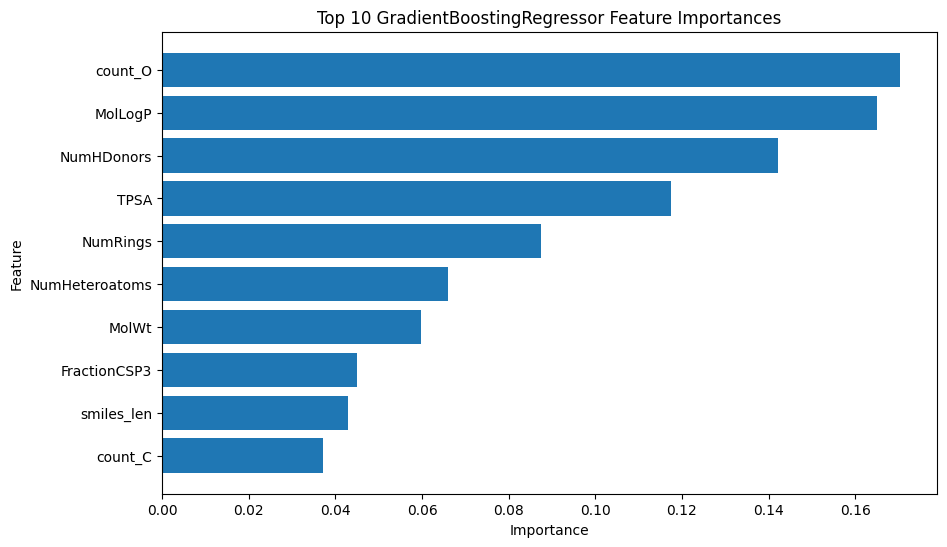

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train_new, y_train_new)

# Make predictions on the validation set
y_pred_gbr = gbr.predict(X_valid_new)

# Compute evaluation metrics
mae_gbr = mean_absolute_error(y_valid_new, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_valid_new, y_pred_gbr))
r2_gbr = r2_score(y_valid_new, y_pred_gbr)

# Print the metrics
print(f"\nGradientBoostingRegressor Validation MAE: {mae_gbr:.4f}")
print(f"GradientBoostingRegressor Validation RMSE: {rmse_gbr:.4f}")
print(f"GradientBoostingRegressor Validation R²: {r2_gbr:.4f}")

# Examine feature importances for GradientBoostingRegressor
importances_gbr = gbr.feature_importances_
feature_names_gbr = X_train_new.columns

forest_importances_gbr = pd.Series(importances_gbr, index=feature_names_gbr)
forest_importances_gbr = forest_importances_gbr.sort_values(ascending=False)

print("\nGradientBoostingRegressor Feature Importances (ranked):")
print(forest_importances_gbr)

plt.figure(figsize=(10, 6))
plt.barh(forest_importances_gbr.index[:10], forest_importances_gbr.values[:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 GradientBoostingRegressor Feature Importances")
plt.show()

### Interpretation of GradientBoostingRegressor Results

The GradientBoostingRegressor achieved a validation R² of **0.5169**. This is slightly **lower** than the RandomForestRegressor's R² of 0.6327 with the same feature set.

**Interpretation:** The `GradientBoostingRegressor` performed slightly worse than the `RandomForestRegressor` on this dataset. This suggests that for this specific problem and feature set, the bagging approach of Random Forest might be more robust or better at capturing the underlying relationships compared to the boosting approach. While both models highlight similar features as important (e.g., MolLogP, count_O, TPSA, NumHDonors), the individual contributions and overall predictive power differed, with Random Forest achieving a higher R².

---
## Sanity checks

Run this cell after you finish CT2.1 -- this only checks that you produced the required outputs, not that they are *good*.

In [22]:
# 1) Extended features file saved
assert (ARTIFACT_DIR / "ffv_features_extended.csv").exists(), \
    "Missing artifacts/ffv_features_extended.csv"

# 2) At least 5 new descriptor columns beyond the original set
original_cols = set(pd.read_csv(ARTIFACT_DIR / "ffv_features_rdkit.csv").columns)
new_cols = set(extended_df.columns) - original_cols
assert len(new_cols) >= 5, f"Add at least 5 new descriptor columns (you added {len(new_cols)})"
print(f"You added {len(new_cols)} new descriptors: {sorted(new_cols)}")

# 3) X / y shapes are consistent
assert X_train.ndim == 2 and X_valid.ndim == 2, "X arrays must be 2D"
assert X_train.shape[1] == X_valid.shape[1], "X_train and X_valid must have the same number of columns"
assert X_train.shape[1] >= 1, "You need at least one feature column"
assert len(y_train) == X_train.shape[0]
assert len(y_valid) == X_valid.shape[0]

print("\nBasic checks passed -- you can submit.")

You added 7 new descriptors: ['FractionCSP3', 'MolLogP', 'NOCount', 'NumAromaticRings', 'NumHDonors', 'NumHeteroatoms', 'NumRings']

Basic checks passed -- you can submit.


---
## Submission

- Submit only this notebook (rename to `CodingTask2_<your_name>.ipynb`) by **email** (matteo.boi@unibe.ch), by **Sunday 2026-05-17, 23:59**.
- Bring your laptop to class on **2026-05-20** -- we will pool everyone's features and experiment together live.